<a href="https://colab.research.google.com/github/esdenadia/NoSQL-Aula2-DynamoDB/blob/master/NLP_RU3554672_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================
# IDENTIFICADOR PESSOAL
# ==============================
contador_RU3554672 = 0


!pip -q install wordcloud nltk

import pandas as pd
import numpy as np
import re, unicodedata
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from wordcloud import WordCloud

In [ ]:
nltk.download('stopwords')
stopwords_pt = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:

CSV_PATH = 'imdb-reviews-pt-br.csv'

df = pd.read_csv(CSV_PATH)
print("Colunas:", list(df.columns))
print(df.head(3))

Colunas: ['id', 'text_en', 'text', 'sentiment']
   id                                            text_en  \
0   1  Once again Mr. Costner has dragged out a movie...   
1   2  This is an example of why the majority of acti...   
2   3  First of all I hate those moronic rappers, who...   

                                                text sentiment  
0  Mais uma vez, o Sr. Costner arrumou um filme p...       neg  
1  Este é um exemplo do motivo pelo qual a maiori...       neg  
2  Primeiro de tudo eu odeio esses raps imbecis, ...       neg  


In [ ]:
# --- Tentar inferir coluna de texto ---
candidatas_texto = ['text', 'review', 'conteudo', 'full_text', 'texto', 'sentence']
col_text = None
for c in candidatas_texto:
    if c in df.columns:
        col_text = c
        break
if col_text is None:
    # pega a primeira coluna do tipo object com textos longos
    obj_cols = [c for c in df.columns if df[c].dtype == 'object']
    if not obj_cols:
        raise ValueError("Não encontrei coluna de texto. Verifique df.columns.")
    col_text = obj_cols[0]

# --- Tentar inferir coluna de rótulo ---
candidatas_label = ['label', 'sentiment', 'class', 'polarity', 'target']
col_label = None
for c in candidatas_label:
    if c in df.columns:
        col_label = c
        break
if col_label is None:
    # pega a segunda coluna (muito comum) ou a primeira object diferente do texto
    obj_cols = [c for c in df.columns if df[c].dtype == 'object' and c != col_text]
    if obj_cols:
        col_label = obj_cols[0]
    else:
        # fallback: segunda coluna
        col_label = df.columns[1]

print("Coluna de texto:", col_text)
print("Coluna de label:", col_label)

# Normalizar labels
lab = df[col_label].astype(str).str.strip().str.upper()

# Mapear POS->REAL, NEG->FAKE (como você pediu)
map_pos = {'POS', 'POSITIVE', 'POSITIVO', '1', 'P'}
map_neg = {'NEG', 'NEGATIVE', 'NEGATIVO', '0', 'N'}

def mapear_label(x):
    if x in map_pos:
        return 'REAL'
    if x in map_neg:
        return 'FAKE'
    # se vier algo diferente, tenta por substring
    if 'POS' in x:
        return 'REAL'
    if 'NEG' in x:
        return 'FAKE'
    return np.nan

df['label_final'] = lab.apply(mapear_label)
df = df.dropna(subset=['label_final', col_text]).copy()

print(df['label_final'].value_counts())

Coluna de texto: text
Coluna de label: sentiment
label_final
FAKE    24765
REAL    24694
Name: count, dtype: int64


In [ ]:
def limpar_texto_pt(texto: str) -> str:
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)          # remove URLs
    texto = re.sub(r'[^a-z\s]', ' ', texto)                 # mantém letras
    texto = re.sub(r'\s+', ' ', texto).strip()              # remove espaços extras
    tokens = [t for t in texto.split() if t not in stopwords_pt and len(t) > 2]
    return " ".join(tokens)

df['texto_limpo'] = df[col_text].apply(limpar_texto_pt)

df[['label_final', col_text, 'texto_limpo']].head(3)

,label_final,text,texto_limpo
0,FAKE,"Mais uma vez, o Sr. Costner arrumou um filme p...",vez costner arrumou filme tempo necessario ale...
1,FAKE,Este é um exemplo do motivo pelo qual a maiori...,exemplo motivo maioria filmes acao sao mesmos ...
2,FAKE,"Primeiro de tudo eu odeio esses raps imbecis, ...",primeiro tudo odeio raps imbecis nao poderiam ...


In [ ]:
X = df['texto_limpo']
y = df['label_final']  # REAL / FAKE

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(
    ngram_range=(1,3),
    max_features=20000,
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# chance de >85% em sentimento
modelo = LogisticRegression(max_iter=2000, n_jobs=-1)
modelo.fit(X_train_tfidf, y_train)

y_pred = modelo.predict(X_test_tfidf)
acuracia = accuracy_score(y_test, y_pred)

print("Acurácia:", acuracia)
print(classification_report(y_test, y_pred))

Acurácia: 0.8971289931257582
              precision    recall  f1-score   support

        FAKE       0.91      0.88      0.90      6191
        REAL       0.89      0.91      0.90      6174

    accuracy                           0.90     12365
   macro avg       0.90      0.90      0.90     12365
weighted avg       0.90      0.90      0.90     12365



In [ ]:
feature_names = vectorizer.get_feature_names_out()

def contar_ngrams(vocab):
    uni = sum(1 for t in vocab if t.count(' ') == 0)
    bi  = sum(1 for t in vocab if t.count(' ') == 1)
    tri = sum(1 for t in vocab if t.count(' ') == 2)
    return uni, bi, tri

uni, bi, tri = contar_ngrams(feature_names)
print("Unigramas:", uni, "| Bigramas:", bi, "| Trigramas:", tri)

Unigramas: 12158 | Bigramas: 7107 | Trigramas: 735


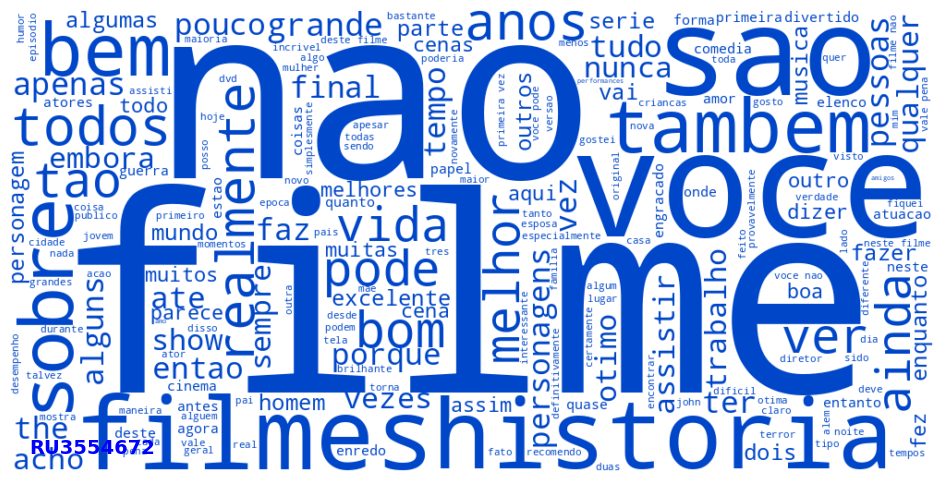

In [ ]:
# Máscara REAL (evita erros pandas/sparse)
y_train_np = pd.Series(y_train).astype(str).str.strip().str.upper().values
mask_real = (y_train_np == 'REAL')

if mask_real.sum() == 0:
    raise ValueError("Nenhum exemplo REAL encontrado no treino. Verifique mapeamento POS->REAL.")

tfidf_real = X_train_tfidf[mask_real].mean(axis=0)
tfidf_real = np.asarray(tfidf_real).ravel()

freq_real = dict(zip(feature_names, tfidf_real))

# Cor fixa AZUL (letras azuis)
def color_func_blue(*args, **kwargs):
    return "rgb(0, 70, 200)"  # azul forte

wc_real = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    collocations=False
).generate_from_frequencies(freq_real)

wc_real = wc_real.recolor(color_func=color_func_blue)

plt.figure(figsize=(12,6))
plt.imshow(wc_real, interpolation='bilinear')
plt.axis('off')
plt.text(20, 480, 'RU3554672', color='blue', fontsize=14, weight='bold')
plt.show()

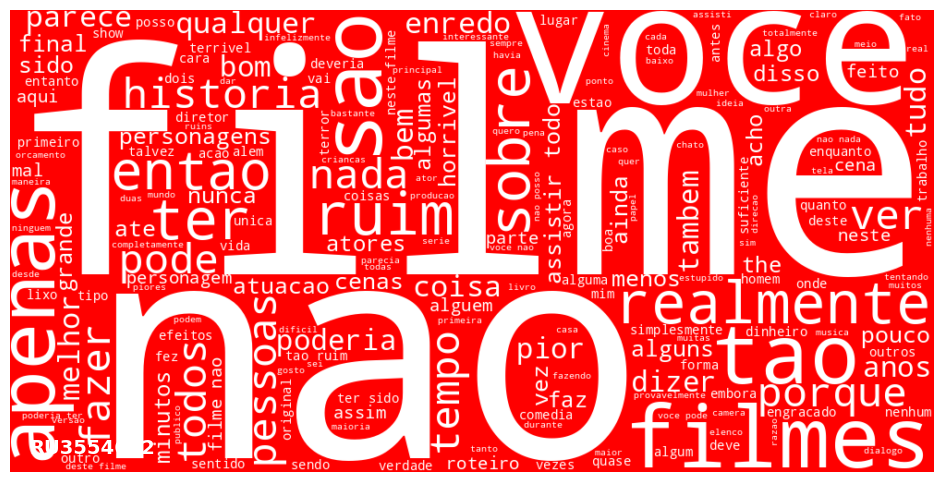

In [ ]:
mask_fake = (y_train_np == 'FAKE')

if mask_fake.sum() == 0:
    raise ValueError("Nenhum exemplo FAKE encontrado no treino. Verifique mapeamento NEG->FAKE.")

tfidf_fake = X_train_tfidf[mask_fake].mean(axis=0)
tfidf_fake = np.asarray(tfidf_fake).ravel()

freq_fake = dict(zip(feature_names, tfidf_fake))

# Cor fixa BRANCA (letras brancas)
def color_func_white(*args, **kwargs):
    return "rgb(255, 255, 255)"

wc_fake = WordCloud(
    width=1000,
    height=500,
    background_color='red',   # fundo vermelho
    collocations=False
).generate_from_frequencies(freq_fake)

wc_fake = wc_fake.recolor(color_func=color_func_white)

plt.figure(figsize=(12,6))
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.text(20, 480, 'RU3554672', color='white', fontsize=14, weight='bold')
plt.show()

In [ ]:
from sklearn.svm import LinearSVC
modelo = LinearSVC()
modelo.fit(X_train_tfidf, y_train)
y_pred = modelo.predict(X_test_tfidf)
acuracia = accuracy_score(y_test, y_pred)
print("Acurácia:", acuracia)

Acurácia: 0.892195713708047


In [ ]:
y_train_np = y_train.astype(str).str.upper().values
mask_fake = (y_train_np == 'FAKE')

print("Quantidade de textos FAKE no treino:", mask_fake.sum())

Quantidade de textos FAKE no treino: 18574


In [ ]:
feature_names = vectorizer.get_feature_names_out()

unigramas = sum(1 for t in feature_names if t.count(' ') == 0)
bigramas  = sum(1 for t in feature_names if t.count(' ') == 1)
trigramas = sum(1 for t in feature_names if t.count(' ') == 2)

print("Unigramas:", unigramas)
print("Bigramas :", bigramas)
print("Trigramas:", trigramas)

Unigramas: 12158
Bigramas : 7107
Trigramas: 735


In [ ]:
feature_names = vectorizer.get_feature_names_out()

In [ ]:
feature_names = vectorizer.get_feature_names_out()

unigramas = sum(1 for t in feature_names if t.count(' ') == 0)
bigramas  = sum(1 for t in feature_names if t.count(' ') == 1)
trigramas = sum(1 for t in feature_names if t.count(' ') == 2)

print("Unigramas:", unigramas)
print("Bigramas :", bigramas)
print("Trigramas:", trigramas)

Unigramas: 12158
Bigramas : 7107
Trigramas: 735
